# LangChain-LangGraph 애플리케이션 테스팅

1. LangChain/LangGraph 테스팅 전략 개요
2. **Unit Testing**: GenericFakeChatModel을 활용한 LLM Mocking
3. **State & Node Testing**: 개별 노드 함수 격리 테스트
4. **Integration Testing**: 실제 LLM을 사용한 End-to-End Integration 테스트
5. **Trajectory Evaluation**: agentevals를 활용한 에이전트 궤적 평가

---

## 1. 테스팅 전략 개요

### 1.1 왜 LLM 애플리케이션 테스팅이 어려운가?

LLM 애플리케이션은 **비결정적(non-deterministic)** 특성 때문에 전통적인 테스팅 방식이 어렵습니다:

| 전통적 애플리케이션 | LLM 애플리케이션 |
|-------------------|------------------|
| 동일 입력 → 동일 출력 | 동일 입력 → 다양한 출력 |
| 명확한 assertion | 의미적 평가 필요 |
| 빠른 실행 | API 호출 지연 |
| 무료 | 호출당 비용 발생 |

### 1.2 테스트 피라미드

```
              ┌─────────────┐
              │ Integration │  ← 실제 LLM, 느리고 비쌈
              │   Tests     │
           ┌──┴─────────────┴──┐
           │   Component Tests │  ← 개별 노드/체인 테스트
        ┌──┴───────────────────┴──┐
        │       Unit Tests        │  ← Fake LLM, 빠르고 저렴
        └─────────────────────────┘
```

### 1.3 핵심 테스팅 도구

| 도구 | 용도 | 비용 |
|------|------|------|
| `GenericFakeChatModel` | LLM 모킹, Unit Test | 무료 |
| `InMemorySaver` | 상태 기반 테스트 | 무료 |
| `agentevals` | 궤적 평가 | 무료/LLM 비용 |
| `pytest-recording` | HTTP 녹화/재생 | 무료 |

---

## 2. 환경 설정

In [2]:
import os
from typing import Annotated, Literal, TypedDict

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain_core.language_models import GenericFakeChatModel
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field

load_dotenv()

True

---

## 3. Unit Testing: GenericFakeChatModel

### 3.1 GenericFakeChatModel 소개

`GenericFakeChatModel`은 LangChain에서 제공하는 **인메모리 LLM Mocking** 도구입니다.  
실제 API 호출 없이 미리 정의된 응답을 반환하여 빠르고 저렴한 테스트가 가능합니다.

**핵심 기능:**
- 문자열 또는 `AIMessage` 시퀀스를 응답으로 설정
- 호출할 때마다 다음 응답을 순차적으로 반환
- 스트리밍(`stream`/`astream`) 지원
- 도구 호출 시뮬레이션 가능

In [ ]:
# 기본 사용법: 문자열 응답 시퀀스
fake_llm = GenericFakeChatModel(
    messages=iter(
        [  # iterator 또는 list 모두 가능
            "안녕하세요! 저는 테스트용 AI입니다.",
            "두 번째 응답입니다.",
            "세 번째 응답입니다.",
        ]
    )
)

# 첫 번째 호출
response1 = fake_llm.invoke([HumanMessage(content="안녕?")])
print(f"1번째 응답: {response1.content}")

# 두 번째 호출
response2 = fake_llm.invoke([HumanMessage(content="두 번째 질문")])
print(f"2번째 응답: {response2.content}")

# 세 번째 호출
response3 = fake_llm.invoke([HumanMessage(content="세 번째 질문")])
print(f"3번째 응답: {response3.content}")

1번째 응답: 안녕하세요! 저는 테스트용 AI입니다.
2번째 응답: 두 번째 응답입니다.
3번째 응답: 세 번째 응답입니다.


### 3.2 AIMessage로 구조화된 응답 모킹

도구 호출이나 메타데이터가 필요한 경우 `AIMessage` 객체를 직접 사용합니다.

In [4]:
# 도구 호출을 포함한 AIMessage 응답
fake_responses = [
    # 첫 번째 응답: 도구 호출
    AIMessage(
        content="",
        tool_calls=[
            {
                "id": "call_123",
                "name": "search",
                "args": {"query": "LangGraph 튜토리얼"},
            }
        ],
    ),
    # 두 번째 응답: 최종 답변
    AIMessage(content="검색 결과를 바탕으로 답변드리겠습니다."),
]

fake_llm_with_tools = GenericFakeChatModel(messages=iter(fake_responses))

# 첫 번째 호출 - 도구 호출 반환
response = fake_llm_with_tools.invoke([HumanMessage(content="LangGraph 알려줘")])
print(f"응답 내용: '{response.content}'")
print(f"도구 호출: {response.tool_calls}")

응답 내용: ''
도구 호출: [{'name': 'search', 'args': {'query': 'LangGraph 튜토리얼'}, 'id': 'call_123', 'type': 'tool_call'}]


### 3.3 실전 예제: Router 패턴 테스트

프로젝트의 `router` 패턴에서 intent 분류 로직을 테스트해봅시다.

In [ ]:
# Intent 분류를 위한 Pydantic 모델
class IntentClassification(BaseModel):
    """Intent classification result."""

    intent: Literal["technical", "business", "casual"] = Field(
        description="Classified intent type"
    )
    confidence: float = Field(description="Confidence score 0-1", ge=0, le=1)
    reasoning: str = Field(description="Reasoning for classification")


# Fake LLM을 사용한 분류 테스트
class FakeClassifierLLM:
    """Fake LLM that returns predefined IntentClassification."""

    def __init__(self, result: IntentClassification):
        """Initialize with a predefined result."""
        self._result = result

    def with_structured_output(self, model_cls):
        """Return a fake structured output chain."""
        return FakeStructuredChain(self._result)


class FakeStructuredChain:
    """Fake chain that returns structured output."""

    def __init__(self, result):
        """Initialize with a predefined result."""
        self._result = result

    async def ainvoke(self, messages):
        """Asynchronously return the predefined result."""
        return self._result

    def invoke(self, messages):
        """Synchronously return the predefined result."""
        return self._result


# 테스트 실행
fake_result = IntentClassification(
    intent="technical",
    confidence=0.92,
    reasoning="질문에 API, 코드 등 기술 용어가 포함됨",
)

fake_llm = FakeClassifierLLM(fake_result)
classifier = fake_llm.with_structured_output(IntentClassification)

result = classifier.invoke([HumanMessage(content="API 호출 방법을 알려주세요")])

print(f"Intent: {result.intent}")
print(f"Confidence: {result.confidence}")
print(f"Reasoning: {result.reasoning}")

# Assertions
assert result.intent == "technical"
assert result.confidence > 0.9

Intent: technical
Confidence: 0.92
Reasoning: 질문에 API, 코드 등 기술 용어가 포함됨


---

## 4. State & Node Testing

### 4.1 노드 함수 격리 테스트

LangGraph의 각 노드 함수는 **순수한 함수**로 설계하면 테스트가 쉬워집니다.  
(그래서 모든 LangGraph 예제 등이 Node 를 함수로 구현하는 것이기도 하죠. 설계도 쉬워지구요.)  
의존성(LLM 등)을 주입 가능하게 만들면 Fake Object로 교체할 수 있습니다.

In [ ]:
# 상태 정의
class PlanExecuteState(TypedDict):
    """Plan-and-Execute 패턴의 상태."""

    input: str
    plan: list[str]
    past_steps: Annotated[list[tuple[str, str]], lambda x, y: x + y]
    response: str


# 테스트할 노드 함수: 계획 생성
async def plan_step(state: PlanExecuteState, *, planner) -> dict:
    """Generate a plan based on input.

    Args:
        state: Current state
        planner: Planner LLM (dependency injection)

    Returns:
        Updated state with plan
    """
    plan = await planner.ainvoke({"input": state["input"]})
    return {"plan": plan.steps}


# Fake Planner
class FakePlanner:
    """Fake planner that returns predefined plan."""

    def __init__(self, steps: list[str]):
        self.steps = steps

    async def ainvoke(self, inputs):
        class FakePlan:
            def __init__(self, steps):
                self.steps = steps

        return FakePlan(self.steps)


# 테스트
async def test_plan_step():
    # Arrange
    fake_planner = FakePlanner(
        [
            "1. 요구사항 분석",
            "2. 리서치 수행",
            "3. 결과 정리",
        ]
    )
    initial_state: PlanExecuteState = {
        "input": "AI 트렌드 조사",
        "plan": [],
        "past_steps": [],
        "response": "",
    }

    # Act
    result = await plan_step(initial_state, planner=fake_planner)

    # Assert
    assert len(result["plan"]) == 3
    assert "요구사항 분석" in result["plan"][0]
    print(f"생성된 계획: {result['plan']}")


await test_plan_step()

생성된 계획: ['1. 요구사항 분석', '2. 리서치 수행', '3. 결과 정리']


### 4.2 라우팅 함수 테스트

Conditional Edge의 라우팅 함수는 LLM 의존성 없이 순수 로직만 테스트할 수 있습니다.

In [ ]:
# 라우팅 함수 정의
def route_by_intent(
    state: dict,
    *,
    confidence_threshold: float = 0.7,
) -> Literal["technical", "business", "casual", "fallback"]:
    """Route based on classified intent and confidence.

    Args:
        state: State containing intent and confidence
        confidence_threshold: Minimum confidence for routing

    Returns:
        Next node name
    """
    intent = state.get("intent", "")
    confidence = state.get("confidence", 0.0)

    if confidence < confidence_threshold:
        return "fallback"

    return intent if intent in ["technical", "business", "casual"] else "fallback"


# 테스트 케이스 여러개 테스트
def test_route_by_intent():
    # 높은 신뢰도 → 해당 intent로 라우팅
    assert route_by_intent({"intent": "technical", "confidence": 0.9}) == "technical"
    assert route_by_intent({"intent": "business", "confidence": 0.85}) == "business"

    # 낮은 신뢰도 → fallback
    assert route_by_intent({"intent": "technical", "confidence": 0.3}) == "fallback"

    # 커스텀 threshold
    assert (
        route_by_intent(
            {"intent": "casual", "confidence": 0.6},
            confidence_threshold=0.5,
        )
        == "casual"
    )

    # 알 수 없는 intent → fallback
    assert route_by_intent({"intent": "unknown", "confidence": 0.99}) == "fallback"


test_route_by_intent()

### 4.3 상태 업데이트 테스트

Annotated reducer 함수가 올바르게 동작하는지 테스트합니다.

In [ ]:
# 메시지 상태 테스트
class MessageState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


def test_add_messages_reducer():
    # 기존 상태
    existing = [HumanMessage(content="안녕")]

    # 새 메시지 추가
    new = [AIMessage(content="안녕하세요!")]

    # add_messages reducer 직접 테스트
    result = add_messages(existing, new)

    assert len(result) == 2
    assert result[0].content == "안녕"
    assert result[1].content == "안녕하세요!"

    print(f"메시지 수: {len(result)}")


test_add_messages_reducer()

메시지 수: 2


---

## 5. InMemorySaver를 활용한 상태 기반 테스트

### 5.1 MemorySaver 개요

`MemorySaver`는 그래프 실행 중 체크포인트를 메모리에 저장하여
**멀티턴 대화**나 **상태 의존적 동작**을 테스트할 수 있게 합니다.

```
Turn 1: User → Graph → Checkpoint 저장
Turn 2: User → Graph (이전 상태 복원) → Checkpoint 저장
Turn 3: ...
```

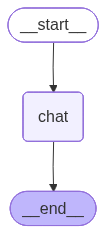

In [ ]:
# 간단한 챗봇 그래프 정의
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    turn_count: int


def chat_node(state: ChatState) -> dict:
    """Echo back the last message with turn count."""
    last_message = state["messages"][-1].content
    turn = state.get("turn_count", 0) + 1

    return {
        "messages": [AIMessage(content=f"[Turn {turn}] Echo: {last_message}")],
        "turn_count": turn,
    }


# 그래프 빌드 (MemorySaver 사용)
workflow = StateGraph(ChatState)
workflow.add_node("chat", chat_node)
workflow.add_edge(START, "chat")
workflow.add_edge("chat", END)

# MemorySaver로 컴파일
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)
app

In [10]:
# 멀티턴 대화 테스트
config = RunnableConfig(configurable={"thread_id": "test-thread-1"})

# Turn 1
result1 = app.invoke(
    {"messages": [HumanMessage(content="안녕하세요")], "turn_count": 0},
    config=config,
)
print(f"Turn 1 응답: {result1['messages'][-1].content}")
print(f"Turn count: {result1['turn_count']}")

# Turn 2 (이전 상태 자동 복원)
result2 = app.invoke(
    {"messages": [HumanMessage(content="두 번째 메시지")]},
    config=config,
)
print(f"\nTurn 2 응답: {result2['messages'][-1].content}")
print(f"Turn count: {result2['turn_count']}")
print(f"총 메시지 수: {len(result2['messages'])}")

# Assertions
assert result2["turn_count"] == 2
assert len(result2["messages"]) == 4  # 2 human + 2 AI

Turn 1 응답: [Turn 1] Echo: 안녕하세요
Turn count: 1

Turn 2 응답: [Turn 2] Echo: 두 번째 메시지
Turn count: 2
총 메시지 수: 4


### 5.2 상태 스냅샷 검증

`get_state()`를 사용하여 저장된 체크포인트를 검증할 수 있습니다.

In [ ]:
# 저장된 상태 확인
snapshot = app.get_state(config)

print("=== 저장된 상태 스냅샷 ===")
print(f"Turn count: {snapshot.values.get('turn_count')}")
print(f"Messages count: {len(snapshot.values.get('messages', []))}")
print(f"Next nodes: {snapshot.next}")
print(f"Config: {snapshot.config}")

# 히스토리 확인
print("\n=== 상태 히스토리 ===")
for i, state in enumerate(app.get_state_history(config)):
    turn = state.values.get("turn_count", 0)
    msg_count = len(state.values.get("messages", []))
    print(f"  Checkpoint {i}: turn_count={turn}, messages={msg_count}")

=== 저장된 상태 스냅샷 ===
Turn count: 2
Messages count: 4
Next nodes: ()
Config: {'configurable': {'thread_id': 'test-thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0d7419-1eca-6a12-8004-3202f117053c'}}

=== 상태 히스토리 ===
  Checkpoint 0: turn_count=2, messages=4
  Checkpoint 1: turn_count=1, messages=3
  Checkpoint 2: turn_count=1, messages=2
  Checkpoint 3: turn_count=1, messages=2
  Checkpoint 4: turn_count=0, messages=1
  Checkpoint 5: turn_count=0, messages=0


---

## 6. Integration Testing

### 6.1 통합 테스트 전략

통합 테스트는 **실제 LLM**을 사용하여 전체 파이프라인을 검증합니다.

**주의사항:**
- API 호출 비용 발생
- 비결정적 결과물 → 유연한 Assertion 필요
- CI/CD에서는 스킵하거나 녹화된 응답 사용

```python
# pytest marker로 통합 테스트 구분
@pytest.mark.integration
async def test_full_pipeline():
    ...
```

In [5]:
# 실제 LLM을 사용한 통합 테스트 예제
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

load_dotenv()


def run_integration_test():
    """Integration test with real LLM."""
    # 실제 LLM 설정
    llm = ChatOpenAI(
        model="gpt-4.1-mini",
        temperature=0,
    )

    # 간단한 호출 테스트
    response = llm.invoke([HumanMessage(content="1+1은?")])

    print(f"LLM 응답: {response.content}")

    # 유연한 assertion (정확한 텍스트가 아닌 의미적 검증 - Semantic)
    assert "2" in response.content, "응답에 '2'가 포함되어야 합니다"


run_integration_test()

LLM 응답: 1+1은 2입니다.


### 6.2 Smoke Test 패턴

**Smoke Test**는 시스템의 기본 동작을 빠르게 확인하는 테스트입니다.  
복잡한 assertion 대신 "오류 없이 실행되는가"를 검증합니다.

In [ ]:
async def smoke_test_graph(
    graph,
    initial_state: dict,
    config: RunnableConfig | None = None,
) -> dict:
    """Run a smoke test on a LangGraph graph.

    Args:
        graph: Compiled LangGraph
        initial_state: Initial state for the graph
        config: Optional config (required if graph has checkpointer)

    Returns:
        Final state after execution

    Raises:
        AssertionError: If the graph fails to execute
    """
    try:
        result = await graph.ainvoke(initial_state, config=config)

        # 기본 검증: 결과가 dict인가?
        assert isinstance(result, dict), "결과가 dict 타입이어야 합니다"

        print(f"   결과 키: {list(result.keys())}")
        return result

    except Exception as e:
        print(f"Smoke test 실패: {e}")
        raise


# 예제: 앞서 만든 chat 그래프에 smoke test 실행
# 참고: checkpointer가 있는 그래프는 반드시 thread_id 제공 필요
smoke_config = RunnableConfig(configurable={"thread_id": "smoke-test-1"})
await smoke_test_graph(
    app,
    {"messages": [HumanMessage(content="테스트")], "turn_count": 0},
    config=smoke_config,
)

   결과 키: ['messages', 'turn_count']


{'messages': [HumanMessage(content='테스트', additional_kwargs={}, response_metadata={}, id='84de7815-8f32-420a-be69-5dd8ec449f57'),
  AIMessage(content='[Turn 1] Echo: 테스트', additional_kwargs={}, response_metadata={}, id='2d607604-78e8-4888-b436-ece781e7a934')],
 'turn_count': 1}

---

## 7. Trajectory Evaluation (agentevals)

### 7.1 Trajectory 평가란?

**Trajectory Evaluation**은 에이전트가 작업을 수행하는 **과정**을 평가합니다.  
최종 결과뿐 아니라 어떤 도구를 어떤 순서로 호출했는지 검증합니다.

```
예상 Trace:  search → analyze → respond
실제 Trace:  search → search → analyze → respond  ← 검증 실패 (strict) / 성공 (subset)
```

### 7.2 agentevals 패키지
> https://github.com/langchain-ai/agentevals

`agentevals`는 두 가지 평가 방식을 제공합니다:

1. **Trajectory Match Evaluator**: 결정적, 빠름, 무료
   - `strict`: 정확히 동일한 순서
   - `unordered`: 같은 도구들, 순서 무관
   - `subset`/`superset`: 부분 일치

2. **LLM-as-Judge Evaluator**: 유연, LLM 비용 발생
   - 루브릭 기반 정성적 평가

In [6]:
# agentevals 설치 확인 및 사용 예제
try:
    from agentevals.trajectory import create_trajectory_match_evaluator
    from langchain_core.messages import AIMessage

    # 1. Trajectory 생성 헬퍼 함수
    # agentevals는 AIMessage 리스트(tool_calls 포함)를 입력으로 받습니다.
    def make_trajectory(tools):
        return [
            AIMessage(
                content="", tool_calls=[{"name": t, "args": {}, "id": f"call_{i}"}]
            )
            for i, t in enumerate(tools)
        ]

    # 2. 예상 궤적 (Reference Trajectory) 정의
    reference_trajectory = make_trajectory(["search", "analyze", "respond"])

    # 3. 평가자 생성
    # 인자 없이 생성 시 기본적으로 strict 모드(순서/도구/인자 정확 일치) 사용
    evaluator = create_trajectory_match_evaluator()

    # 4. 실제 궤적 테스트

    # Case A: 정확히 일치하는 경우
    print("--- Case A: Exact Match ---")
    trajectory_a = make_trajectory(["search", "analyze", "respond"])
    # evaluator는 (outputs, reference_outputs) 인자를 받는 함수입니다.
    result_a = evaluator(outputs=trajectory_a, reference_outputs=reference_trajectory)
    print(f"Trajectory Tools: {['search', 'analyze', 'respond']}")
    print(f"Score: {result_a['score']} (Expected: True)\n")

    # Case B: 불일치하는 경우 (중복 호출)
    print("--- Case B: Mismatch (Extra Step) ---")
    trajectory_b = make_trajectory(["search", "search", "analyze", "respond"])
    result_b = evaluator(outputs=trajectory_b, reference_outputs=reference_trajectory)
    print(f"Trajectory Tools: {['search', 'search', 'analyze', 'respond']}")
    print(f"Score: {result_b['score']} (Expected: False)\n")

except ImportError:
    print("⚠️ agentevals 패키지가 설치되어 있지 않습니다.")
    print("   설치: pip install agentevals")
except Exception as e:
    print(f"⚠️ 오류 발생: {e}")

--- Case A: Exact Match ---
Trajectory Tools: ['search', 'analyze', 'respond']
Score: True (Expected: True)

--- Case B: Mismatch (Extra Step) ---
Trajectory Tools: ['search', 'search', 'analyze', 'respond']
Score: False (Expected: False)



---

## 8. LangChain 을 활용하는 Application Test 를 만드는 Best Practices

### 8.1 테스트 구조 가이드

```python
# tests/
# ├── conftest.py          # 공통 fixtures
# ├── unit/
# │   ├── test_nodes.py    # 노드 함수 단위 테스트
# │   └── test_routing.py  # 라우팅 로직 테스트
# ├── component/
# │   └── test_chains.py   # 체인/그래프 컴포넌트 테스트
# └── integration/
#     └── test_e2e.py      # 실제 LLM E2E 테스트
```

### 8.2 pytest 설정 예시

```python
# pyproject.toml
[tool.pytest.ini_options]
markers = [
    "integration: 실제 API를 호출하는 통합 테스트 (비용 발생 가능)",
]
asyncio_mode = "auto"

# 실행 예시
# uv run pytest                        # 모든 테스트
# uv run pytest -m "not integration"   # 통합 테스트 제외
# uv run pytest -m integration         # 통합 테스트만
```

### 8.3 Fixture 패턴

```python
# conftest.py
import pytest
from langchain_core.language_models import GenericFakeChatModel

@pytest.fixture
def fake_llm():
    """Provide a fake LLM for unit tests."""
    return GenericFakeChatModel(
        messages=iter(["Default response"])
    )

@pytest.fixture
def real_llm():
    """Provide a real LLM for integration tests."""
    from langchain_openai import ChatOpenAI
    return ChatOpenAI(
        model="gpt-4.1",
        temperature=0,
    )
```

---

## 정리

### 핵심 포인트

1. **테스트 피라미드**: Unit → Component → Integration 순으로 테스트 수 줄이기
2. **GenericFakeChatModel**: LLM 모킹으로 빠르고 저렴한 Unit Test
3. **의존성 주입**: 노드 함수에 LLM을 인자로 전달하여 테스트 가능하게 설계
4. **MemorySaver**: 멀티턴 대화의 상태 의존적 동작 테스트
5. **Trajectory Evaluation**: 결과뿐 아니라 과정(도구 호출 순서 등)도 검증
6. **pytest markers**: `@pytest.mark.integration`으로 비용 발생 테스트 구분

---

## 참고 자료

- [LangChain Testing Documentation](https://docs.langchain.com/oss/python/langchain/test)
- [agentevals - Trajectory Evaluation](https://github.com/langchain-ai/agentevals)
- [pytest-recording - HTTP 녹화/재생](https://github.com/kiwicom/pytest-recording)